# Working With datasets

This tutorial is a sequel to [Tutorial 01](https://lc.llnl.gov/jupyter/user/cdoutrix/notebooks/git/Kosh/examples/Example_01_Add_Data_To_Datasets.ipynb) which should have been successfully ran before this tutotrial.

In this tutorial we will open a store, look for some datasets of interest, search for failed nodes and time, and mark the datasets as failed if necessary.


## Connect to store (using sina local file)


In [1]:
from  kosh import KoshStore
import os

# local tutorial sql file
kosh_example_sql_file = "kosh_example.sql"

# connect to store
store = KoshStore(engine="sina", username=os.environ["USER"], sql='sql', db_path=kosh_example_sql_file)

## Looping through datasets

Let's look for our "IBM project"-related datsets

In [2]:
datasets = store.search(project="IBM")
print("We identified {} possible datasets".format(len(datasets)))

We identified 320 possible datasets


## Working with datasets and files.

Now we are going to identify failed nodes and their earliest time of failure.


In [47]:
import numpy
def identify_bad_nodes(file, metrics=["metrics_0", "metrics_3", "metrics_4"], threshold=0.):
    for i, metric in enumerate(metrics):
        print("\tMetric:", metric)
        h5pointer = file["node"][metric]
        num_cycles = h5pointer.shape[0]
        # eliminate first 3rd of run
        start = num_cycles - 2*num_cycles//3
        start = 0
        print("\t\t", h5pointer.shape, start)
        data = h5pointer[start:]
        print("\t\t", data.shape, data.min(), data.max())
        bad = numpy.argwhere(data<=threshold)
        if bad.shape[0] == 0:
            print("\t\tNo bad nodes! Yeah for success")
        else:
            bad_nodes = list(set(bad[:,1]))
            print("\t\tFor",metric, "There are", len(bad_nodes), "actual bad nodes", bad.shape, bad[0], bad[-1])
            print("\t\tTotal bad_nodes was", bad.shape[0], "which is ", bad.shape[0]/data.size*100., "%")
            mn = 12222222
            mx = 0
            for b in bad_nodes:
                indices = numpy.argwhere(bad[:,1]==b)
                mn = min(mn, indices.shape[0])
                mx = max(mx, indices.shape[0])
                import matplotlib.pyplot as plt
                node = h5pointer[:,b]
                diff = node[:-1] - node[1:]
                #print(b, diff.max())
                if diff.max() !=0:
                    plt.plot(node)
            #    out.append([b, numpy.take(bad[:,0], indices).min()])
            #    print(numpy.take(bad[:,0], indices))
            print("mn, mx", mn, mx)
            plt.legend()
            plt.show()
# Keeping only datsets for which hdf5 is available
#for ds in datasets[10:11]:
#    print("looking at:", ds.name, ds.__associated_data__)
#    hdf5 = ds.search(type="hdf5")
#    if len(hdf5)>0:
#        print("Found an hdf5 file")
#        h5 = hdf5[0]
#        identify_bad_nodes(h5.open())
        
            

In [33]:
f =h5.open()
metric = "metrics_0"
data = f["node"][metric]
diff = data[:-1] - data[1:]
print("mn, mx", diff.min(), diff.max())

mn, mx -0.000683367 0.00045936217


In [37]:
h5.uri

'/p/lscratchh/cdoutrix/cdoutrix/IBM/workaround/base/molar.1_shock.1.1_taper.0.2_skew.0.8/IBM/res.2_molar.1_shock.1.1_taper.0.2_skew.0.8.hdf5'

In [39]:
error = '/p/lscratchh/cdoutrix/cdoutrix/IBM/workaround/base/molar.1_shock.1.7_taper.0.6_skew.0.8/slurm-340974.out'
no_error = '/p/lscratchh/cdoutrix/cdoutrix/IBM/workaround/base/molar.1_shock.1.3_taper.0.6_skew.0.6/slurm-340933.out'
error_goal_reached = '/p/lscratchh/cdoutrix/cdoutrix/IBM/workaround/base/molar.0.3_shock.1.3_taper.0.8_skew.0.9/slurm-340778.out'

Using i loader: <kosh.sina.core.KoshSinaFileLoader object at 0x2aaabd7fe780>
	Metric: metrics_0
		 (33560, 10323) 0
		 (33560, 10323) -3.9989013e-06 0.124435216
		For metrics_0 There are 407 actual bad nodes (13558244, 2) [0 0] [33559  7898]
		Total bad_nodes was 13558244 which is  3.9135921649666896 %


mn, mx 1 33560


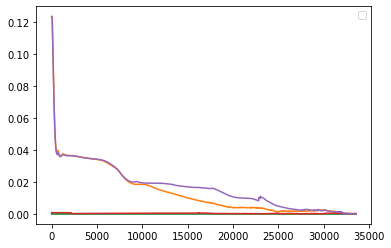

	Metric: metrics_3
		 (33560, 10323) 0
		 (33560, 10323) -1.3997349e-05 0.12436262
		For metrics_3 There are 439 actual bad nodes (13558525, 2) [0 0] [33559  7898]
		Total bad_nodes was 13558525 which is  3.913673275721028 %


mn, mx 1 33560


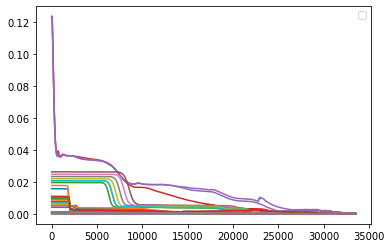

	Metric: metrics_4
		 (33560, 10323) 0
		 (33560, 10323) -1.3997349e-05 0.12436262
		For metrics_4 There are 439 actual bad nodes (13558525, 2) [0 0] [33559  7898]
		Total bad_nodes was 13558525 which is  3.913673275721028 %


mn, mx 1 33560


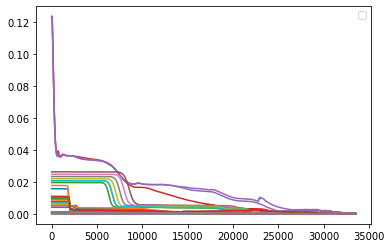

In [49]:
ds = store.search(name='molar.1_shock.1.7_taper.0.6_skew.0.8')
h5 = ds[0].search(type="hdf5")[0]
identify_bad_nodes(h5.open())

In [ ]:
ds.__associated_data__

In [ ]:
from sina.model import Record
Record(id="fgfg", type="schema")
Record.add_data(self=Record,name="IBM", value={})

In [ ]:
ds.search(type="kull")

In [ ]:
store.loadFromStore("963345a8f44d11e9a17b001e67a135ba")